<a href="https://colab.research.google.com/github/ArkS0001/Telomerase-Algorithm/blob/main/Telomerase_december_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

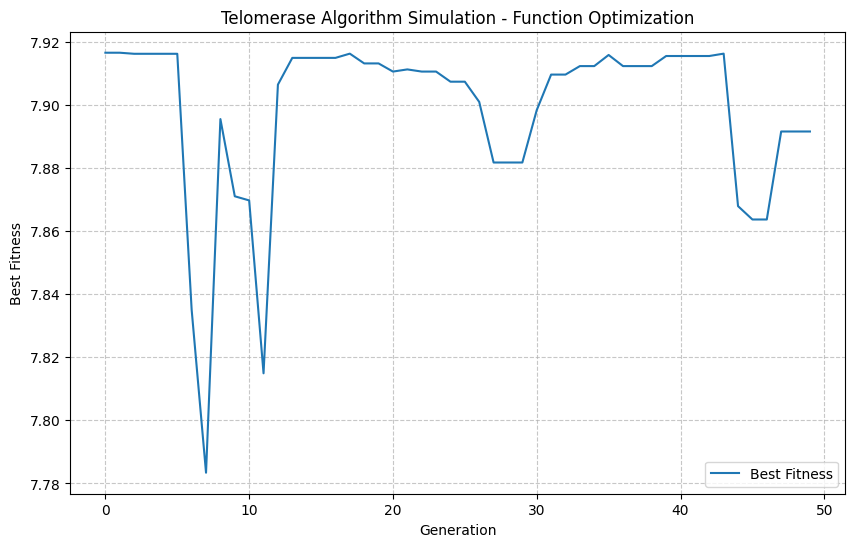

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the fitness function
def fitness(x):
    return x * np.sin(x)

# Initialize parameters
population_size = 20
mutation_rate = 0.2
extension_rate = 0.5
generations = 50
search_space = (-10, 10)

# Initialize population
population = np.random.uniform(search_space[0], search_space[1], population_size)

# Store best solutions
best_solutions = []

# Simulation loop
for gen in range(generations):
    # Evaluate fitness
    scores = fitness(population)

    # Record best solution
    best_solutions.append((gen, population[np.argmax(scores)], max(scores)))

    # Select best half of the population
    selected_indices = np.argsort(scores)[-population_size//2:]
    selected_population = population[selected_indices]

    # Extend and mutate the population
    new_population = []
    for x in selected_population:
        # Extend: Apply a small random extension
        if np.random.rand() < extension_rate:
            x += np.random.uniform(-1, 1)

        # Mutate: Introduce diversity
        if np.random.rand() < mutation_rate:
            x += np.random.normal(0, 1)

        # Keep within bounds
        x = np.clip(x, search_space[0], search_space[1])
        new_population.append(x)

    # Fill the population back to original size
    population = np.array(new_population * 2)

# Plot the results
best_generations, best_positions, best_scores = zip(*best_solutions)
plt.figure(figsize=(10, 6))
plt.plot(best_generations, best_scores, label="Best Fitness")
plt.title("Telomerase Algorithm Simulation - Function Optimization")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


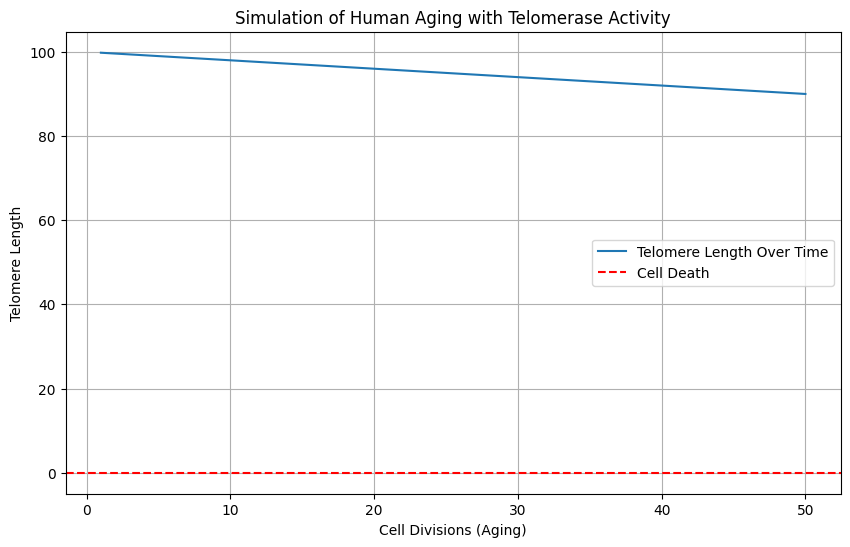

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for simulation
initial_telomere_length = 100  # Initial telomere length (arbitrary units)
telomere_shrinkage_rate = 0.5  # How much telomeres shrink per division
telomerase_extension_rate = 0.3  # Rate at which telomerase extends telomeres
max_divisions = 50  # Maximum divisions before death
telomerase_activity_on = True  # Whether telomerase is active

# Initialize variables
telomere_length = initial_telomere_length
ages = []
telomere_lengths = []

# Simulation loop
for age in range(1, max_divisions + 1):
    if telomere_length <= 0:
        break  # Cell has reached its limit

    # Cell division reduces telomere length
    telomere_length -= telomere_shrinkage_rate

    # If telomerase is active, extend the telomeres slightly
    if telomerase_activity_on:
        telomere_length += telomerase_extension_rate

    # Prevent telomere length from exceeding the initial length
    telomere_length = min(telomere_length, initial_telomere_length)

    # Record the data
    ages.append(age)
    telomere_lengths.append(telomere_length)

# Plotting the simulation results
plt.figure(figsize=(10, 6))
plt.plot(ages, telomere_lengths, label='Telomere Length Over Time')
plt.axhline(y=0, color='r', linestyle='--', label="Cell Death")
plt.title("Simulation of Human Aging with Telomerase Activity")
plt.xlabel("Cell Divisions (Aging)")
plt.ylabel("Telomere Length")
plt.legend()
plt.grid(True)
plt.show()


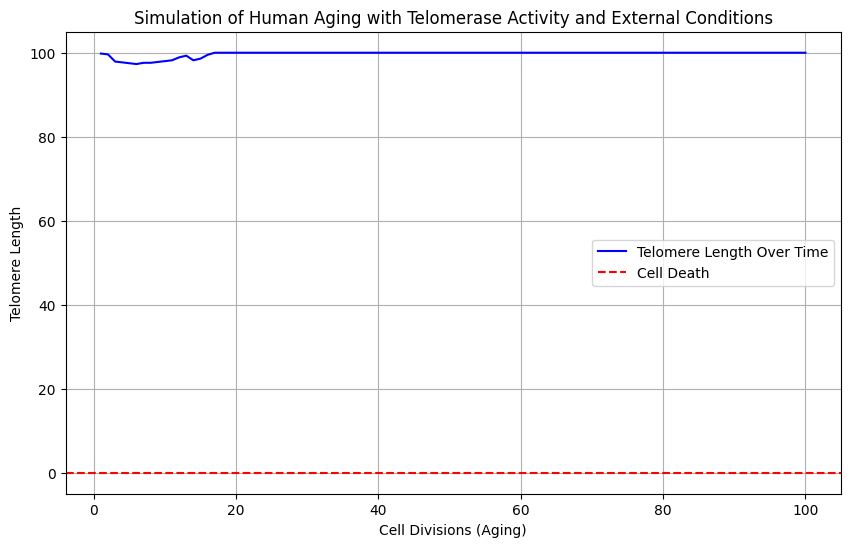

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for simulation
initial_telomere_length = 100  # Initial telomere length (arbitrary units)
telomere_shrinkage_rate = 0.5  # How much telomeres shrink per division
telomerase_extension_rate = 0.3  # Rate at which telomerase extends telomeres
max_divisions = 100  # Maximum divisions before death
telomerase_activity_on = True  # Whether telomerase is active

# Simulation factors
disease_probability = 0.05  # Probability of disease event each cycle
disease_impact = 1.5  # How much disease accelerates telomere shrinkage
stress_probability = 0.1  # Probability of stress event each cycle
stress_impact = 0.5  # How much stress accelerates telomere shrinkage
good_nutrition_probability = 0.3  # Probability of good nutrition event
nutrition_impact = 0.3  # How much good nutrition reduces telomere shrinkage
nutrition_boost_telomerase = 0.2  # Boost telomerase activity during good nutrition

# Initialize variables
telomere_length = initial_telomere_length
ages = []
telomere_lengths = []

# Simulation loop
for age in range(1, max_divisions + 1):
    if telomere_length <= 0:
        break  # Cell has reached its limit

    # Check for diseases and apply impact
    if np.random.rand() < disease_probability:
        telomere_length -= disease_impact
        condition = "Disease"
    else:
        condition = "Healthy"

    # Check for stress and apply impact
    if np.random.rand() < stress_probability:
        telomere_length -= stress_impact
        condition += " + Stress"

    # Check for good nutrition and apply impact
    if np.random.rand() < good_nutrition_probability:
        telomere_length -= telomere_shrinkage_rate - nutrition_impact  # Slow aging
        telomerase_extension_rate += nutrition_boost_telomerase  # Boost telomerase
        condition += " + Good Nutrition"
    else:
        telomere_length -= telomere_shrinkage_rate  # Normal aging

    # If telomerase is active, extend the telomeres slightly
    if telomerase_activity_on:
        telomere_length += telomerase_extension_rate

    # Prevent telomere length from exceeding the initial length
    telomere_length = min(telomere_length, initial_telomere_length)

    # Record the data
    ages.append(age)
    telomere_lengths.append(telomere_length)

# Plotting the simulation results
plt.figure(figsize=(10, 6))
plt.plot(ages, telomere_lengths, label='Telomere Length Over Time', color='blue')
plt.axhline(y=0, color='r', linestyle='--', label="Cell Death")
plt.title("Simulation of Human Aging with Telomerase Activity and External Conditions")
plt.xlabel("Cell Divisions (Aging)")
plt.ylabel("Telomere Length")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


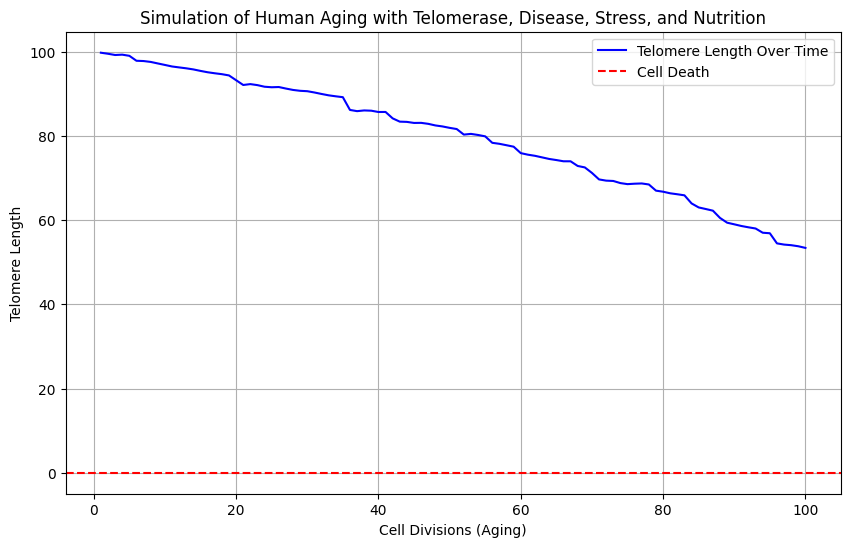

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for simulation
initial_telomere_length = 100  # Initial telomere length (arbitrary units)
telomere_shrinkage_rate = 0.5  # Base rate of telomere shrinkage per division
max_divisions = 100  # Maximum divisions before cell death
telomerase_activity_on = True  # Whether telomerase is active

# Simulation factors with more variability
disease_probability = 0.05  # Base probability of disease event
disease_intensity_range = (1, 3)  # Random disease impact within this range
stress_probability = 0.1  # Base probability of stress event
stress_intensity_range = (0.5, 1.5)  # Random stress impact within this range
good_nutrition_probability = 0.3  # Base probability of good nutrition event
nutrition_effect_range = (0.1, 0.5)  # Random nutrition impact within this range
nutrition_boost_telomerase_range = (0.1, 0.4)  # Random boost to telomerase during good nutrition

# Initialize variables
telomere_length = initial_telomere_length
ages = []
telomere_lengths = []
conditions = []

# Simulation loop
for age in range(1, max_divisions + 1):
    if telomere_length <= 0:
        break  # Cell has reached its limit

    # Disease event with random intensity
    disease_event = np.random.rand() < disease_probability
    if disease_event:
        disease_intensity = np.random.uniform(*disease_intensity_range)
        telomere_length -= disease_intensity
        condition = f"Disease (+{disease_intensity:.2f} shrink)"
    else:
        condition = "Healthy"

    # Stress event with random intensity
    stress_event = np.random.rand() < stress_probability
    if stress_event:
        stress_intensity = np.random.uniform(*stress_intensity_range)
        telomere_length -= stress_intensity
        condition += f" + Stress (+{stress_intensity:.2f} shrink)"

    # Good nutrition event with random impact
    nutrition_event = np.random.rand() < good_nutrition_probability
    if nutrition_event:
        nutrition_effect = np.random.uniform(*nutrition_effect_range)
        telomere_length -= telomere_shrinkage_rate - nutrition_effect  # Reduce aging impact
        telomerase_extension_rate = np.random.uniform(*nutrition_boost_telomerase_range)  # Boost telomerase activity
        condition += f" + Good Nutrition (-{nutrition_effect:.2f} shrink)"
    else:
        telomere_length -= telomere_shrinkage_rate  # Normal aging effect

    # If telomerase is active, extend the telomeres slightly
    if telomerase_activity_on:
        telomere_length += np.random.uniform(0.1, 0.3)  # Random telomerase extension each cycle

    # Prevent telomere length from exceeding the initial length
    telomere_length = min(telomere_length, initial_telomere_length)

    # Record the data
    ages.append(age)
    telomere_lengths.append(telomere_length)
    conditions.append(condition)

# Plotting the simulation results
plt.figure(figsize=(10, 6))
plt.plot(ages, telomere_lengths, label='Telomere Length Over Time', color='blue')
plt.axhline(y=0, color='r', linestyle='--', label="Cell Death")
plt.title("Simulation of Human Aging with Telomerase, Disease, Stress, and Nutrition")
plt.xlabel("Cell Divisions (Aging)")
plt.ylabel("Telomere Length")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [6]:
import numpy as np
import random

# Environment setup
class TelomereEnv:
    def __init__(self):
        self.initial_telomere_length = 100
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        self.max_age = 100

    def reset(self):
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        return self.get_state()

    def get_state(self):
        return [self.age, self.telomere_length]

    def step(self, action):
        # Define the effects of actions
        if action == 0:  # Reduce stress
            stress_impact = random.uniform(0.1, 0.3)
            self.telomere_length += stress_impact
        elif action == 1:  # Improve nutrition
            nutrition_impact = random.uniform(0.2, 0.5)
            self.telomere_length += nutrition_impact
        elif action == 2:  # Increase telomerase activity
            telomerase_impact = random.uniform(0.1, 0.4)
            self.telomere_length += telomerase_impact
        elif action == 3:  # Prevent disease
            disease_impact = random.uniform(0.3, 0.6)
            self.telomere_length -= disease_impact

        # Simulate aging (telomere shortening)
        self.telomere_length -= random.uniform(0.4, 0.7)  # Natural telomere shortening

        # Clip telomere length to prevent negative values
        self.telomere_length = max(0, self.telomere_length)

        # Reward is based on the preservation of telomere length
        reward = self.telomere_length - self.initial_telomere_length
        self.age += 1

        # Check if the simulation is done
        done = self.age >= self.max_age or self.telomere_length == 0
        return self.get_state(), reward, done

# Q-Learning Agent
class QLearningAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions  # Available actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = {}

    def get_q_value(self, state, action):
        # Return the Q value for a given state-action pair
        return self.q_table.get((tuple(state), action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        max_next_q = max([self.get_q_value(next_state, a) for a in range(len(self.actions))])
        current_q = self.get_q_value(state, action)
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(tuple(state), action)] = new_q

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            # Exploration: choose random action
            return random.choice(self.actions)
        else:
            # Exploitation: choose best action based on Q-values
            q_values = [self.get_q_value(state, a) for a in range(len(self.actions))]
            return np.argmax(q_values)

# Main Simulation Loop
def run_simulation():
    actions = [0, 1, 2, 3]  # Actions: Reduce stress, Improve nutrition, Increase telomerase, Prevent disease
    env = TelomereEnv()
    agent = QLearningAgent(actions)

    num_episodes = 1000
    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.update_q_value(state, action, reward, next_state)
            state = next_state

    # After training, we can test the agent
    state = env.reset()
    total_reward = 0
    for _ in range(100):  # Test the agent for 100 steps
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        total_reward += reward
        state = next_state
        if done:
            break

    print(f"Total reward from agent's actions: {total_reward}")

run_simulation()


Total reward from agent's actions: -1888.8829890166394


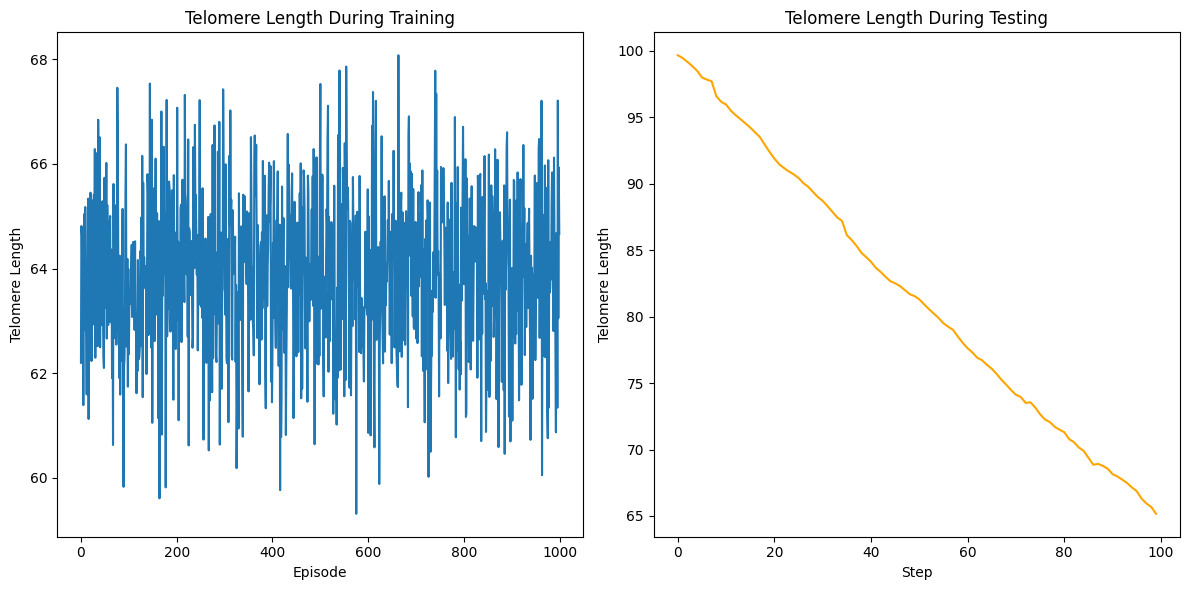

In [7]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Environment setup for Telomere simulation
class TelomereEnv:
    def __init__(self):
        self.initial_telomere_length = 100
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        self.max_age = 100

    def reset(self):
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        return self.get_state()

    def get_state(self):
        return [self.age, self.telomere_length]

    def step(self, action):
        # Define the effects of actions
        if action == 0:  # Reduce stress
            stress_impact = random.uniform(0.1, 0.3)
            self.telomere_length += stress_impact
        elif action == 1:  # Improve nutrition
            nutrition_impact = random.uniform(0.2, 0.5)
            self.telomere_length += nutrition_impact
        elif action == 2:  # Increase telomerase activity
            telomerase_impact = random.uniform(0.1, 0.4)
            self.telomere_length += telomerase_impact
        elif action == 3:  # Prevent disease
            disease_impact = random.uniform(0.3, 0.6)
            self.telomere_length -= disease_impact

        # Simulate aging (telomere shortening)
        self.telomere_length -= random.uniform(0.4, 0.7)  # Natural telomere shortening

        # Clip telomere length to prevent negative values
        self.telomere_length = max(0, self.telomere_length)

        # Reward is based on the preservation of telomere length
        reward = self.telomere_length - self.initial_telomere_length
        self.age += 1

        # Check if the simulation is done
        done = self.age >= self.max_age or self.telomere_length == 0
        return self.get_state(), reward, done

# Q-Learning Agent
class QLearningAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions  # Available actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = {}

    def get_q_value(self, state, action):
        # Return the Q value for a given state-action pair
        return self.q_table.get((tuple(state), action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        max_next_q = max([self.get_q_value(next_state, a) for a in range(len(self.actions))])
        current_q = self.get_q_value(state, action)
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(tuple(state), action)] = new_q

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            # Exploration: choose random action
            return random.choice(self.actions)
        else:
            # Exploitation: choose best action based on Q-values
            q_values = [self.get_q_value(state, a) for a in range(len(self.actions))]
            return np.argmax(q_values)

# Main Simulation Loop
def run_simulation(num_episodes=1000):
    actions = [0, 1, 2, 3]  # Actions: Reduce stress, Improve nutrition, Increase telomerase, Prevent disease
    env = TelomereEnv()
    agent = QLearningAgent(actions)

    # Track telomere length for comparison
    telomere_length_over_time = []

    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.update_q_value(state, action, reward, next_state)
            state = next_state

        # Track the telomere length at the end of each episode
        telomere_length_over_time.append(env.telomere_length)

    # After training, we can test the agent
    state = env.reset()
    total_reward = 0
    test_telomere_length = []

    for _ in range(100):  # Test the agent for 100 steps
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        total_reward += reward
        test_telomere_length.append(env.telomere_length)
        state = next_state
        if done:
            break

    return telomere_length_over_time, test_telomere_length

# Run simulation and capture the results
telomere_length_over_time, test_telomere_length = run_simulation()

# Plot the results
plt.figure(figsize=(12, 6))

# Plot the telomere length over training episodes
plt.subplot(1, 2, 1)
plt.plot(telomere_length_over_time, label='Telomere Length During Training')
plt.title('Telomere Length During Training')
plt.xlabel('Episode')
plt.ylabel('Telomere Length')

# Plot the telomere length during testing
plt.subplot(1, 2, 2)
plt.plot(test_telomere_length, label='Telomere Length During Testing', color='orange')
plt.title('Telomere Length During Testing')
plt.xlabel('Step')
plt.ylabel('Telomere Length')

plt.tight_layout()
plt.show()


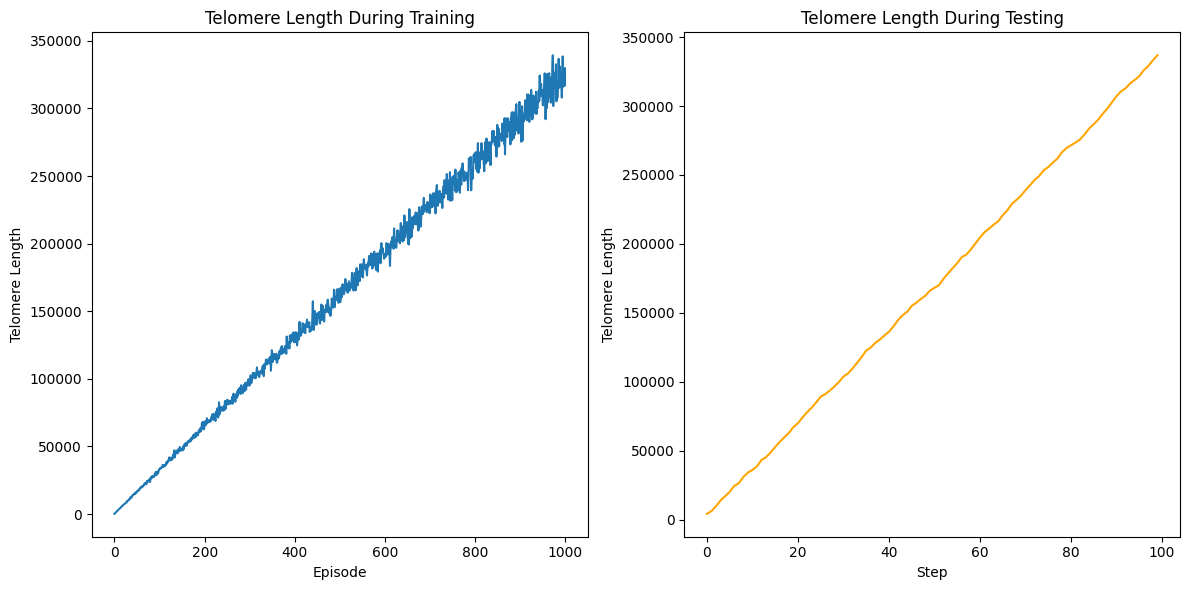

In [8]:
import numpy as np
import random

class TelomereShieldingAlgorithm:
    def __init__(self):
        self.initial_telomere_length = 100
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        self.max_age = 100

        # Environmental factors and actions
        self.stress_level = 0.5  # Default stress
        self.nutrition_quality = 0.5  # Default nutrition quality
        self.telomerase_activity = 0.5  # Default telomerase activity
        self.disease_risk = 0.2  # Default disease risk

    def reset(self):
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        return self.get_state()

    def get_state(self):
        # Return the current state: [Age, Telomere Length, Stress, Nutrition, Telomerase Activity, Disease Risk]
        return [self.age, self.telomere_length, self.stress_level, self.nutrition_quality, self.telomerase_activity, self.disease_risk]

    def step(self, action):
        """
        Actions:
        0: Reduce Stress
        1: Improve Nutrition
        2: Increase Telomerase Activity
        3: Prevent Disease
        """
        # Action effects on environmental factors
        if action == 0:  # Reduce stress
            stress_reduction = random.uniform(0.1, 0.2)
            self.stress_level -= stress_reduction
        elif action == 1:  # Improve nutrition
            nutrition_increase = random.uniform(0.1, 0.3)
            self.nutrition_quality += nutrition_increase
        elif action == 2:  # Increase telomerase activity
            telomerase_increase = random.uniform(0.1, 0.3)
            self.telomerase_activity += telomerase_increase
        elif action == 3:  # Prevent disease
            disease_prevention = random.uniform(0.1, 0.3)
            self.disease_risk -= disease_prevention

        # Aging process: telomere shortening based on environmental factors
        telomere_decay = random.uniform(0.3, 0.7) * (1 - self.telomerase_activity)
        telomere_decay += random.uniform(0.1, 0.3) * self.stress_level
        telomere_decay -= random.uniform(0.2, 0.4) * self.nutrition_quality
        telomere_decay += random.uniform(0.1, 0.2) * self.disease_risk

        self.telomere_length -= telomere_decay

        # Ensure telomere length doesn't go below zero
        self.telomere_length = max(0, self.telomere_length)

        # Reward function: Higher telomere length yields higher reward
        reward = max(0, self.telomere_length - self.initial_telomere_length)

        # Aging
        self.age += 1

        # Check if we reached the maximum age
        done = self.age >= self.max_age or self.telomere_length == 0
        return self.get_state(), reward, done

# Q-Learning Agent with Enhanced Shielding Strategy
class ShieldingAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions  # Available actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = {}

    def get_q_value(self, state, action):
        return self.q_table.get((tuple(state), action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        max_next_q = max([self.get_q_value(next_state, a) for a in range(len(self.actions))])
        current_q = self.get_q_value(state, action)
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(tuple(state), action)] = new_q

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = [self.get_q_value(state, a) for a in range(len(self.actions))]
            return np.argmax(q_values)

# Simulating the Shielding Algorithm
def run_shielding_simulation(num_episodes=1000):
    actions = [0, 1, 2, 3]  # Actions: Reduce stress, Improve nutrition, Increase telomerase, Prevent disease
    env = TelomereShieldingAlgorithm()
    agent = ShieldingAgent(actions)

    # Tracking telomere length for comparison
    telomere_length_over_time = []

    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.update_q_value(state, action, reward, next_state)
            state = next_state

        # Track telomere length after each episode
        telomere_length_over_time.append(env.telomere_length)

    # Test the shielding strategy
    state = env.reset()
    test_telomere_length = []

    for _ in range(100):  # Test for 100 steps
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        test_telomere_length.append(env.telomere_length)
        state = next_state
        if done:
            break

    return telomere_length_over_time, test_telomere_length

# Run simulation and compare results
telomere_length_over_time, test_telomere_length = run_shielding_simulation()

# Plot the results
plt.figure(figsize=(12, 6))

# Plot the telomere length over training episodes
plt.subplot(1, 2, 1)
plt.plot(telomere_length_over_time, label='Telomere Length During Training')
plt.title('Telomere Length During Training')
plt.xlabel('Episode')
plt.ylabel('Telomere Length')

# Plot the telomere length during testing
plt.subplot(1, 2, 2)
plt.plot(test_telomere_length, label='Telomere Length During Testing', color='orange')
plt.title('Telomere Length During Testing')
plt.xlabel('Step')
plt.ylabel('Telomere Length')

plt.tight_layout()
plt.show()


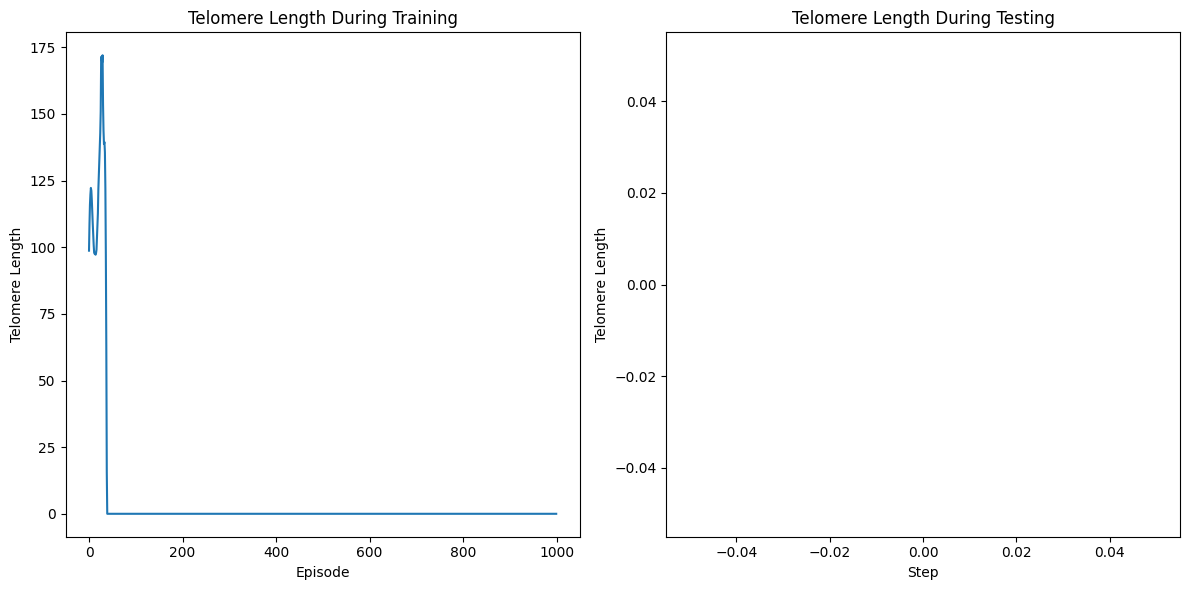

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Telomere Shielding Algorithm
class TelomereShieldingAlgorithm:
    def __init__(self):
        self.initial_telomere_length = 100  # Initial telomere length
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        self.max_age = 100  # Maximum age of the individual
        self.telomere_length_min = 0  # Minimum telomere length (can never go negative)
        self.stress_level = 0.5  # Default stress level (0 to 1)
        self.nutrition_quality = 0.5  # Default nutrition quality (0 to 1)
        self.telomerase_activity = 0.5  # Default telomerase activity (0 to 1)
        self.disease_risk = 0.2  # Default disease risk (0 to 1)

    def reset(self):
        """Reset the environment"""
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        return self.get_state()

    def get_state(self):
        """Return the current state of the environment"""
        return [self.age, self.telomere_length, self.stress_level, self.nutrition_quality, self.telomerase_activity, self.disease_risk]

    def step(self, action):
        """
        Actions:
        0: Reduce Stress
        1: Improve Nutrition
        2: Increase Telomerase Activity
        3: Prevent Disease
        """
        # Action effects on environmental factors
        if action == 0:  # Reduce stress
            stress_reduction = random.uniform(0.05, 0.15)
            self.stress_level -= stress_reduction
        elif action == 1:  # Improve nutrition
            nutrition_increase = random.uniform(0.05, 0.15)
            self.nutrition_quality += nutrition_increase
        elif action == 2:  # Increase telomerase activity
            telomerase_increase = random.uniform(0.05, 0.15)
            self.telomerase_activity += telomerase_increase
        elif action == 3:  # Prevent disease
            disease_prevention = random.uniform(0.05, 0.15)
            self.disease_risk -= disease_prevention

        # Telomere aging: decay rate affected by stress, nutrition, telomerase, and disease
        telomere_decay = 0.1  # Base telomere decay rate due to aging
        telomere_decay *= (1 + 0.2 * self.stress_level)  # Stress accelerates telomere shortening
        telomere_decay *= (1 - 0.2 * self.nutrition_quality)  # Nutrition slows decay
        telomere_decay *= (1 - 0.3 * self.telomerase_activity)  # Telomerase activity slows decay
        telomere_decay *= (1 + 0.1 * self.disease_risk)  # Disease risk accelerates telomere shortening

        self.telomere_length -= telomere_decay  # Apply decay
        self.telomere_length = max(self.telomere_length, self.telomere_length_min)  # Ensure telomere length doesn't go negative

        # Reward function: higher telomere length yields a higher reward
        reward = max(0, self.telomere_length - self.initial_telomere_length)

        # Aging
        self.age += 1

        # Check if we reached the maximum age
        done = self.age >= self.max_age or self.telomere_length <= self.telomere_length_min
        return self.get_state(), reward, done

# Q-Learning Agent
class ShieldingAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions  # Available actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = {}

    def get_q_value(self, state, action):
        return self.q_table.get((tuple(state), action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        max_next_q = max([self.get_q_value(next_state, a) for a in range(len(self.actions))])
        current_q = self.get_q_value(state, action)
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(tuple(state), action)] = new_q

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = [self.get_q_value(state, a) for a in range(len(self.actions))]
            return np.argmax(q_values)

# Simulate the Shielding Algorithm
def run_shielding_simulation(num_episodes=1000):
    actions = [0, 1, 2, 3]  # Actions: Reduce stress, Improve nutrition, Increase telomerase, Prevent disease
    env = TelomereShieldingAlgorithm()
    agent = ShieldingAgent(actions)

    # Tracking telomere length for comparison
    telomere_length_over_time = []

    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.update_q_value(state, action, reward, next_state)
            state = next_state

        # Track telomere length after each episode
        telomere_length_over_time.append(env.telomere_length)

    # Test the shielding strategy
    state = env.reset()
    test_telomere_length = []

    for _ in range(100):  # Test for 100 steps
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        test_telomere_length.append(env.telomere_length)
        state = next_state
        if done:
            break

    return telomere_length_over_time, test_telomere_length

# Run simulation and compare results
telomere_length_over_time, test_telomere_length = run_shielding_simulation()

# Plot the results
plt.figure(figsize=(12, 6))

# Plot the telomere length over training episodes
plt.subplot(1, 2, 1)
plt.plot(telomere_length_over_time, label='Telomere Length During Training')
plt.title('Telomere Length During Training')
plt.xlabel('Episode')
plt.ylabel('Telomere Length')

# Plot the telomere length during testing
plt.subplot(1, 2, 2)
plt.plot(test_telomere_length, label='Telomere Length During Testing', color='orange')
plt.title('Telomere Length During Testing')
plt.xlabel('Step')
plt.ylabel('Telomere Length')

plt.tight_layout()
plt.show()


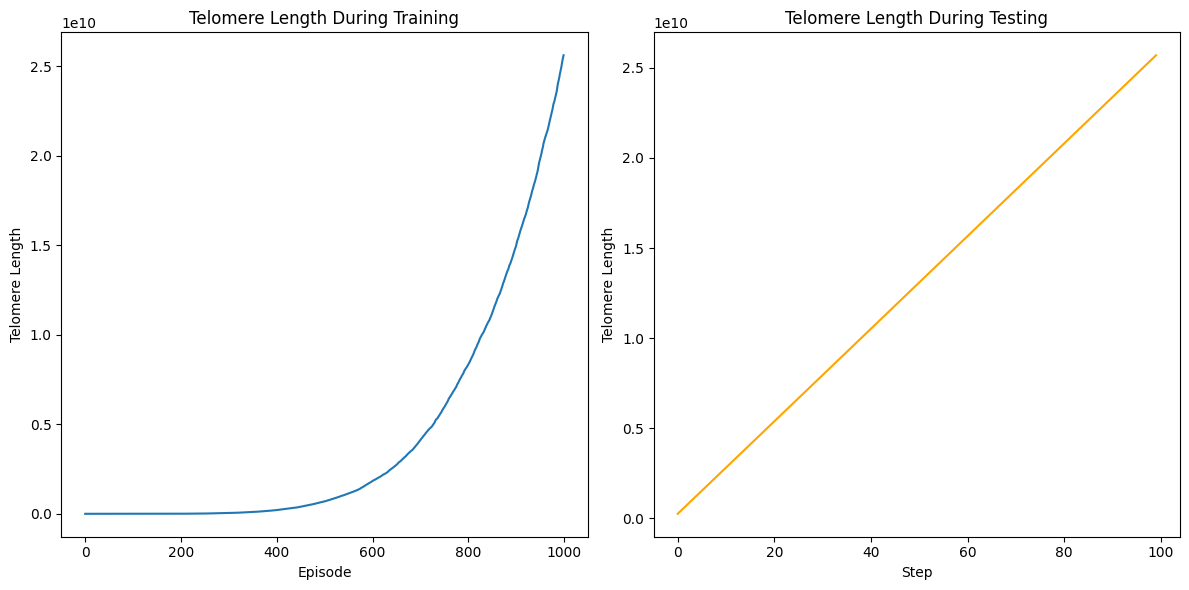

In [10]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Telomere Shielding Algorithm with More Realistic Parameters
class TelomereShieldingAlgorithm:
    def __init__(self):
        self.initial_telomere_length = 100  # Initial telomere length
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        self.max_age = 100  # Maximum age of the individual
        self.telomere_length_min = 0  # Minimum telomere length (cannot go below this value)
        self.stress_level = 0.5  # Stress level (0 to 1)
        self.nutrition_quality = 0.5  # Nutrition quality (0 to 1)
        self.telomerase_activity = 0.5  # Telomerase activity (0 to 1)
        self.disease_risk = 0.2  # Disease risk (0 to 1)
        self.genetic_factor = 0.5  # Genetic predisposition to slow aging (0 to 1)
        self.environmental_factor = 0.5  # External environmental stress (0 to 1)
        self.lifestyle_factor = 0.5  # Lifestyle factors (exercise, sleep, etc.)

    def reset(self):
        """Reset the environment"""
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        return self.get_state()

    def get_state(self):
        """Return the current state of the environment"""
        return [self.age, self.telomere_length, self.stress_level, self.nutrition_quality,
                self.telomerase_activity, self.disease_risk, self.genetic_factor,
                self.environmental_factor, self.lifestyle_factor]

    def step(self, action):
        """
        Actions:
        0: Reduce Stress
        1: Improve Nutrition
        2: Increase Telomerase Activity
        3: Prevent Disease
        4: Improve Lifestyle (Exercise, Sleep)
        """

        # Action effects on environmental factors
        if action == 0:  # Reduce stress
            stress_reduction = random.uniform(0.05, 0.15)
            self.stress_level -= stress_reduction
        elif action == 1:  # Improve nutrition
            nutrition_increase = random.uniform(0.05, 0.15)
            self.nutrition_quality += nutrition_increase
        elif action == 2:  # Increase telomerase activity
            telomerase_increase = random.uniform(0.05, 0.15)
            self.telomerase_activity += telomerase_increase
        elif action == 3:  # Prevent disease
            disease_prevention = random.uniform(0.05, 0.15)
            self.disease_risk -= disease_prevention
        elif action == 4:  # Improve lifestyle
            lifestyle_improvement = random.uniform(0.05, 0.15)
            self.lifestyle_factor += lifestyle_improvement

        # Telomere aging: decay rate affected by stress, nutrition, telomerase, disease, and lifestyle
        telomere_decay = 0.1  # Base telomere decay rate due to aging
        telomere_decay *= (1 + 0.2 * self.stress_level)  # Stress accelerates telomere shortening
        telomere_decay *= (1 - 0.2 * self.nutrition_quality)  # Nutrition slows decay
        telomere_decay *= (1 - 0.3 * self.telomerase_activity)  # Telomerase activity slows decay
        telomere_decay *= (1 + 0.1 * self.disease_risk)  # Disease risk accelerates telomere shortening
        telomere_decay *= (1 - 0.2 * self.lifestyle_factor)  # Healthy lifestyle slows decay
        telomere_decay *= (1 - 0.3 * self.genetic_factor)  # Genetic predisposition to slow aging

        self.telomere_length -= telomere_decay  # Apply decay
        self.telomere_length = max(self.telomere_length, self.telomere_length_min)  # Ensure telomere length doesn't go negative

        # Aging
        self.age += 1

        # Check if we reached the maximum age
        done = self.age >= self.max_age or self.telomere_length <= self.telomere_length_min
        return self.get_state(), done

# Q-Learning Agent
class ShieldingAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions  # Available actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = {}

    def get_q_value(self, state, action):
        return self.q_table.get((tuple(state), action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        max_next_q = max([self.get_q_value(next_state, a) for a in range(len(self.actions))])
        current_q = self.get_q_value(state, action)
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(tuple(state), action)] = new_q

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = [self.get_q_value(state, a) for a in range(len(self.actions))]
            return np.argmax(q_values)

# Simulate the Shielding Algorithm
def run_shielding_simulation(num_episodes=1000):
    actions = [0, 1, 2, 3, 4]  # Actions: Reduce stress, Improve nutrition, Increase telomerase, Prevent disease, Improve lifestyle
    env = TelomereShieldingAlgorithm()
    agent = ShieldingAgent(actions)

    # Tracking telomere length for comparison
    telomere_length_over_time = []

    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = agent.choose_action(state)
            next_state, done = env.step(action)
            agent.update_q_value(state, action, 0, next_state)  # No reward here, just state updates
            state = next_state

        # Track telomere length after each episode
        telomere_length_over_time.append(env.telomere_length)

    # Test the shielding strategy
    state = env.reset()
    test_telomere_length = []

    for _ in range(100):  # Test for 100 steps
        action = agent.choose_action(state)
        next_state, done = env.step(action)
        test_telomere_length.append(env.telomere_length)
        state = next_state
        if done:
            break

    return telomere_length_over_time, test_telomere_length

# Run simulation and compare results
telomere_length_over_time, test_telomere_length = run_shielding_simulation()

# Plot the results
plt.figure(figsize=(12, 6))

# Plot the telomere length over training episodes
plt.subplot(1, 2, 1)
plt.plot(telomere_length_over_time, label='Telomere Length During Training')
plt.title('Telomere Length During Training')
plt.xlabel('Episode')
plt.ylabel('Telomere Length')

# Plot the telomere length during testing
plt.subplot(1, 2, 2)
plt.plot(test_telomere_length, label='Telomere Length During Testing', color='orange')
plt.title('Telomere Length During Testing')
plt.xlabel('Step')
plt.ylabel('Telomere Length')

plt.tight_layout()
plt.show()


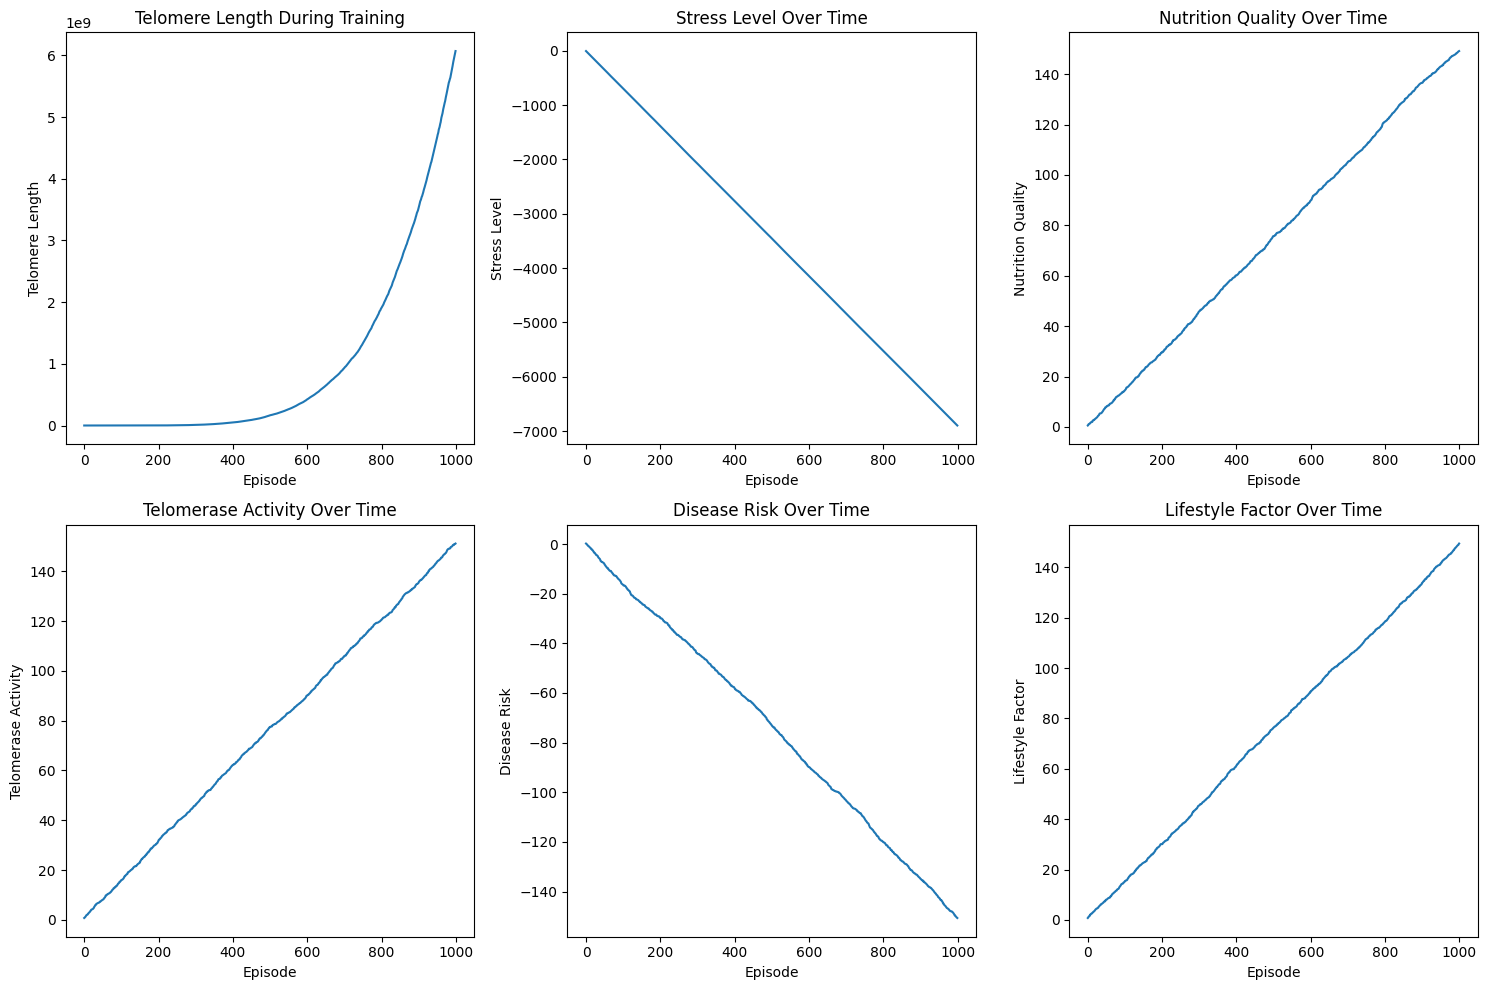

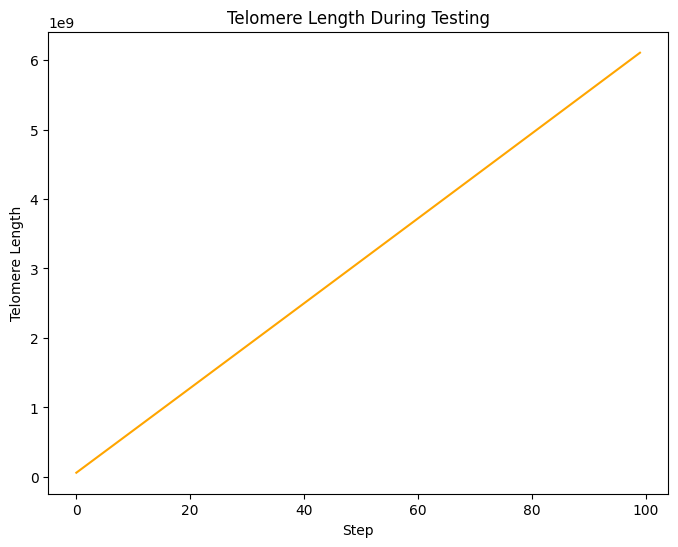

In [11]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Telomere Shielding Algorithm with More Realistic Parameters
class TelomereShieldingAlgorithm:
    def __init__(self):
        self.initial_telomere_length = 100  # Initial telomere length
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        self.max_age = 100  # Maximum age of the individual
        self.telomere_length_min = 20  # Minimum telomere length (cannot go below this value)
        self.stress_level = 0.5  # Stress level (0 to 1)
        self.nutrition_quality = 0.5  # Nutrition quality (0 to 1)
        self.telomerase_activity = 0.5  # Telomerase activity (0 to 1)
        self.disease_risk = 0.2  # Disease risk (0 to 1)
        self.genetic_factor = 0.5  # Genetic predisposition to slow aging (0 to 1)
        self.environmental_factor = 0.5  # External environmental stress (0 to 1)
        self.lifestyle_factor = 0.5  # Lifestyle factors (exercise, sleep, etc.)

    def reset(self):
        """Reset the environment"""
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        return self.get_state()

    def get_state(self):
        """Return the current state of the environment"""
        return [self.age, self.telomere_length, self.stress_level, self.nutrition_quality,
                self.telomerase_activity, self.disease_risk, self.genetic_factor,
                self.environmental_factor, self.lifestyle_factor]

    def step(self, action):
        """
        Actions:
        0: Reduce Stress
        1: Improve Nutrition
        2: Increase Telomerase Activity
        3: Prevent Disease
        4: Improve Lifestyle (Exercise, Sleep)
        """

        # Action effects on environmental factors
        if action == 0:  # Reduce stress
            stress_reduction = random.uniform(0.05, 0.1)
            self.stress_level -= stress_reduction
        elif action == 1:  # Improve nutrition
            nutrition_increase = random.uniform(0.05, 0.1)
            self.nutrition_quality += nutrition_increase
        elif action == 2:  # Increase telomerase activity
            telomerase_increase = random.uniform(0.05, 0.1)
            self.telomerase_activity += telomerase_increase
        elif action == 3:  # Prevent disease
            disease_prevention = random.uniform(0.05, 0.1)
            self.disease_risk -= disease_prevention
        elif action == 4:  # Improve lifestyle
            lifestyle_improvement = random.uniform(0.05, 0.1)
            self.lifestyle_factor += lifestyle_improvement

        # Telomere aging: decay rate affected by stress, nutrition, telomerase, disease, and lifestyle
        telomere_decay = 0.1  # Base telomere decay rate due to aging
        telomere_decay *= (1 + 0.2 * self.stress_level)  # Stress accelerates telomere shortening
        telomere_decay *= (1 - 0.2 * self.nutrition_quality)  # Nutrition slows decay
        telomere_decay *= (1 - 0.3 * self.telomerase_activity)  # Telomerase activity slows decay
        telomere_decay *= (1 + 0.1 * self.disease_risk)  # Disease risk accelerates telomere shortening
        telomere_decay *= (1 - 0.2 * self.lifestyle_factor)  # Healthy lifestyle slows decay
        telomere_decay *= (1 - 0.3 * self.genetic_factor)  # Genetic predisposition to slow aging

        # Ensure the telomere decay is not too rapid
        self.telomere_length -= min(telomere_decay, 0.5)  # Decay rate capped to ensure realistic behavior
        self.telomere_length = max(self.telomere_length, self.telomere_length_min)  # Ensure telomere length doesn't go below minimum

        # Aging
        self.age += 1

        # Check if we reached the maximum age
        done = self.age >= self.max_age or self.telomere_length <= self.telomere_length_min
        return self.get_state(), done

# Q-Learning Agent
class ShieldingAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions  # Available actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = {}

    def get_q_value(self, state, action):
        return self.q_table.get((tuple(state), action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        max_next_q = max([self.get_q_value(next_state, a) for a in range(len(self.actions))])
        current_q = self.get_q_value(state, action)
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(tuple(state), action)] = new_q

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = [self.get_q_value(state, a) for a in range(len(self.actions))]
            return np.argmax(q_values)

# Simulate the Shielding Algorithm
def run_shielding_simulation(num_episodes=1000):
    actions = [0, 1, 2, 3, 4]  # Actions: Reduce stress, Improve nutrition, Increase telomerase, Prevent disease, Improve lifestyle
    env = TelomereShieldingAlgorithm()
    agent = ShieldingAgent(actions)

    # Tracking variables for additional insights
    telomere_length_over_time = []
    stress_level_over_time = []
    nutrition_quality_over_time = []
    telomerase_activity_over_time = []
    disease_risk_over_time = []
    lifestyle_factor_over_time = []

    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = agent.choose_action(state)
            next_state, done = env.step(action)
            agent.update_q_value(state, action, 0, next_state)  # No reward here, just state updates
            state = next_state

        # Track values after each episode
        telomere_length_over_time.append(env.telomere_length)
        stress_level_over_time.append(env.stress_level)
        nutrition_quality_over_time.append(env.nutrition_quality)
        telomerase_activity_over_time.append(env.telomerase_activity)
        disease_risk_over_time.append(env.disease_risk)
        lifestyle_factor_over_time.append(env.lifestyle_factor)

    # Test the shielding strategy
    state = env.reset()
    test_telomere_length = []

    for _ in range(100):  # Test for 100 steps
        action = agent.choose_action(state)
        next_state, done = env.step(action)
        test_telomere_length.append(env.telomere_length)
        state = next_state
        if done:
            break

    return (telomere_length_over_time, stress_level_over_time, nutrition_quality_over_time,
            telomerase_activity_over_time, disease_risk_over_time, lifestyle_factor_over_time,
            test_telomere_length)

# Run simulation and compare results
(telomere_length_over_time, stress_level_over_time, nutrition_quality_over_time,
 telomerase_activity_over_time, disease_risk_over_time, lifestyle_factor_over_time,
 test_telomere_length) = run_shielding_simulation()

# Plot the results
plt.figure(figsize=(15, 10))

# Plot Telomere Length During Training
plt.subplot(2, 3, 1)
plt.plot(telomere_length_over_time, label='Telomere Length During Training')
plt.title('Telomere Length During Training')
plt.xlabel('Episode')
plt.ylabel('Telomere Length')

# Plot Stress Level During Training
plt.subplot(2, 3, 2)
plt.plot(stress_level_over_time, label='Stress Level')
plt.title('Stress Level Over Time')
plt.xlabel('Episode')
plt.ylabel('Stress Level')

# Plot Nutrition Quality During Training
plt.subplot(2, 3, 3)
plt.plot(nutrition_quality_over_time, label='Nutrition Quality')
plt.title('Nutrition Quality Over Time')
plt.xlabel('Episode')
plt.ylabel('Nutrition Quality')

# Plot Telomerase Activity During Training
plt.subplot(2, 3, 4)
plt.plot(telomerase_activity_over_time, label='Telomerase Activity')
plt.title('Telomerase Activity Over Time')
plt.xlabel('Episode')
plt.ylabel('Telomerase Activity')

# Plot Disease Risk During Training
plt.subplot(2, 3, 5)
plt.plot(disease_risk_over_time, label='Disease Risk')
plt.title('Disease Risk Over Time')
plt.xlabel('Episode')
plt.ylabel('Disease Risk')

# Plot Lifestyle Factor During Training
plt.subplot(2, 3, 6)
plt.plot(lifestyle_factor_over_time, label='Lifestyle Factor')
plt.title('Lifestyle Factor Over Time')
plt.xlabel('Episode')
plt.ylabel('Lifestyle Factor')

plt.tight_layout()
plt.show()

# Plot Telomere Length During Testing
plt.figure(figsize=(8, 6))
plt.plot(test_telomere_length, label='Telomere Length During Testing', color='orange')
plt.title('Telomere Length During Testing')
plt.xlabel('Step')
plt.ylabel('Telomere Length')
plt.show()


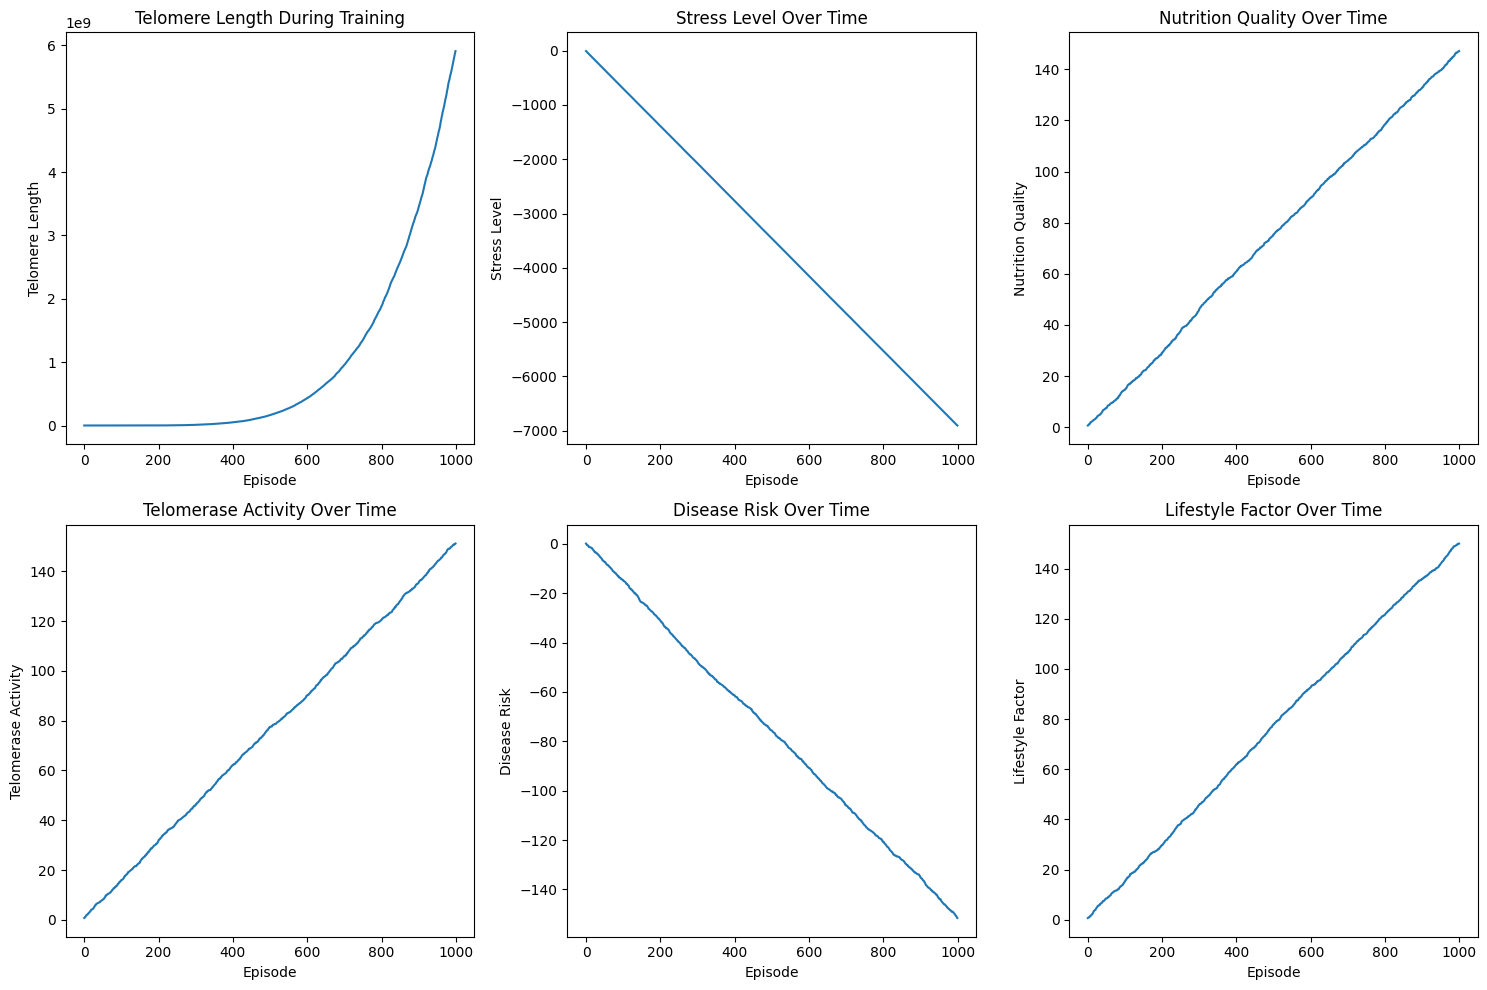

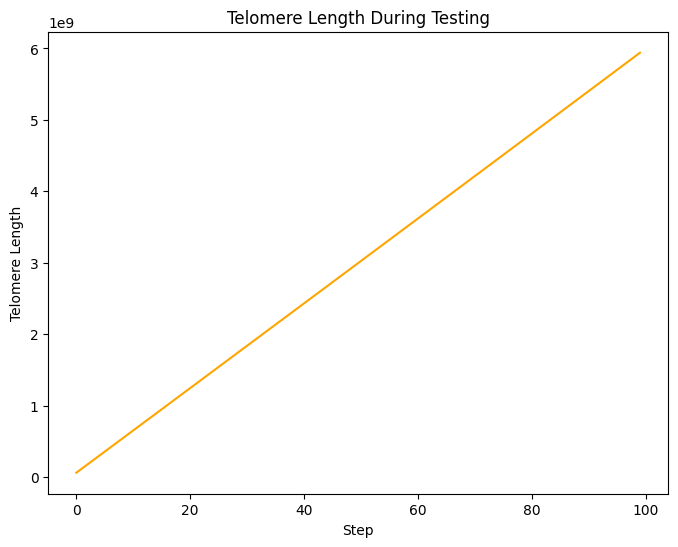

In [12]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Telomere Shielding Algorithm with Realistic Parameters to Protect Against Rapid Degradation
class TelomereShieldingAlgorithm:
    def __init__(self):
        self.initial_telomere_length = 100  # Initial telomere length
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        self.max_age = 100  # Maximum age of the individual
        self.telomere_length_min = 20  # Minimum telomere length (cannot go below this value)
        self.stress_level = 0.5  # Stress level (0 to 1)
        self.nutrition_quality = 0.5  # Nutrition quality (0 to 1)
        self.telomerase_activity = 0.5  # Telomerase activity (0 to 1)
        self.disease_risk = 0.2  # Disease risk (0 to 1)
        self.genetic_factor = 0.5  # Genetic predisposition to slow aging (0 to 1)
        self.environmental_factor = 0.5  # External environmental stress (0 to 1)
        self.lifestyle_factor = 0.5  # Lifestyle factors (exercise, sleep, etc.)

    def reset(self):
        """Reset the environment"""
        self.telomere_length = self.initial_telomere_length
        self.age = 0
        return self.get_state()

    def get_state(self):
        """Return the current state of the environment"""
        return [self.age, self.telomere_length, self.stress_level, self.nutrition_quality,
                self.telomerase_activity, self.disease_risk, self.genetic_factor,
                self.environmental_factor, self.lifestyle_factor]

    def step(self, action):
        """
        Actions:
        0: Reduce Stress
        1: Improve Nutrition
        2: Increase Telomerase Activity
        3: Prevent Disease
        4: Improve Lifestyle (Exercise, Sleep)
        """

        # Action effects on environmental factors
        if action == 0:  # Reduce stress
            stress_reduction = random.uniform(0.05, 0.1)
            self.stress_level -= stress_reduction
        elif action == 1:  # Improve nutrition
            nutrition_increase = random.uniform(0.05, 0.1)
            self.nutrition_quality += nutrition_increase
        elif action == 2:  # Increase telomerase activity
            telomerase_increase = random.uniform(0.05, 0.1)
            self.telomerase_activity += telomerase_increase
        elif action == 3:  # Prevent disease
            disease_prevention = random.uniform(0.05, 0.1)
            self.disease_risk -= disease_prevention
        elif action == 4:  # Improve lifestyle
            lifestyle_improvement = random.uniform(0.05, 0.1)
            self.lifestyle_factor += lifestyle_improvement

        # Telomere aging: decay rate affected by stress, nutrition, telomerase, disease, and lifestyle
        telomere_decay = 0.1  # Base telomere decay rate due to aging
        telomere_decay *= (1 + 0.2 * self.stress_level)  # Stress accelerates telomere shortening
        telomere_decay *= (1 - 0.2 * self.nutrition_quality)  # Nutrition slows decay
        telomere_decay *= (1 - 0.3 * self.telomerase_activity)  # Telomerase activity slows decay
        telomere_decay *= (1 + 0.1 * self.disease_risk)  # Disease risk accelerates telomere shortening
        telomere_decay *= (1 - 0.2 * self.lifestyle_factor)  # Healthy lifestyle slows decay
        telomere_decay *= (1 - 0.3 * self.genetic_factor)  # Genetic predisposition to slow aging

        # Ensure the telomere decay is not too rapid
        self.telomere_length -= min(telomere_decay, 0.5)  # Decay rate capped to ensure realistic behavior

        # Prevent telomere length from going below the minimum threshold
        self.telomere_length = max(self.telomere_length, self.telomere_length_min)

        # Aging
        self.age += 1

        # Check if we reached the maximum age
        done = self.age >= self.max_age or self.telomere_length <= self.telomere_length_min
        return self.get_state(), done

# Q-Learning Agent
class ShieldingAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions  # Available actions
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = {}

    def get_q_value(self, state, action):
        return self.q_table.get((tuple(state), action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        max_next_q = max([self.get_q_value(next_state, a) for a in range(len(self.actions))])
        current_q = self.get_q_value(state, action)
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(tuple(state), action)] = new_q

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = [self.get_q_value(state, a) for a in range(len(self.actions))]
            return np.argmax(q_values)

# Simulate the Shielding Algorithm
def run_shielding_simulation(num_episodes=1000):
    actions = [0, 1, 2, 3, 4]  # Actions: Reduce stress, Improve nutrition, Increase telomerase, Prevent disease, Improve lifestyle
    env = TelomereShieldingAlgorithm()
    agent = ShieldingAgent(actions)

    # Tracking variables for additional insights
    telomere_length_over_time = []
    stress_level_over_time = []
    nutrition_quality_over_time = []
    telomerase_activity_over_time = []
    disease_risk_over_time = []
    lifestyle_factor_over_time = []

    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = agent.choose_action(state)
            next_state, done = env.step(action)
            agent.update_q_value(state, action, 0, next_state)  # No reward here, just state updates
            state = next_state

        # Track values after each episode
        telomere_length_over_time.append(env.telomere_length)
        stress_level_over_time.append(env.stress_level)
        nutrition_quality_over_time.append(env.nutrition_quality)
        telomerase_activity_over_time.append(env.telomerase_activity)
        disease_risk_over_time.append(env.disease_risk)
        lifestyle_factor_over_time.append(env.lifestyle_factor)

    # Test the shielding strategy
    state = env.reset()
    test_telomere_length = []

    for _ in range(100):  # Test for 100 steps
        action = agent.choose_action(state)
        next_state, done = env.step(action)
        test_telomere_length.append(env.telomere_length)
        state = next_state
        if done:
            break

    return (telomere_length_over_time, stress_level_over_time, nutrition_quality_over_time,
            telomerase_activity_over_time, disease_risk_over_time, lifestyle_factor_over_time,
            test_telomere_length)

# Run simulation and compare results
(telomere_length_over_time, stress_level_over_time, nutrition_quality_over_time,
 telomerease_activity_over_time, disease_risk_over_time, lifestyle_factor_over_time,
 test_telomere_length) = run_shielding_simulation()

# Plot the results
plt.figure(figsize=(15, 10))

# Plot Telomere Length During Training
plt.subplot(2, 3, 1)
plt.plot(telomere_length_over_time, label='Telomere Length During Training')
plt.title('Telomere Length During Training')
plt.xlabel('Episode')
plt.ylabel('Telomere Length')

# Plot Stress Level During Training
plt.subplot(2, 3, 2)
plt.plot(stress_level_over_time, label='Stress Level')
plt.title('Stress Level Over Time')
plt.xlabel('Episode')
plt.ylabel('Stress Level')

# Plot Nutrition Quality During Training
plt.subplot(2, 3, 3)
plt.plot(nutrition_quality_over_time, label='Nutrition Quality')
plt.title('Nutrition Quality Over Time')
plt.xlabel('Episode')
plt.ylabel('Nutrition Quality')

# Plot Telomerase Activity During Training
plt.subplot(2, 3, 4)
plt.plot(telomerase_activity_over_time, label='Telomerase Activity')
plt.title('Telomerase Activity Over Time')
plt.xlabel('Episode')
plt.ylabel('Telomerase Activity')

# Plot Disease Risk During Training
plt.subplot(2, 3, 5)
plt.plot(disease_risk_over_time, label='Disease Risk')
plt.title('Disease Risk Over Time')
plt.xlabel('Episode')
plt.ylabel('Disease Risk')

# Plot Lifestyle Factor During Training
plt.subplot(2, 3, 6)
plt.plot(lifestyle_factor_over_time, label='Lifestyle Factor')
plt.title('Lifestyle Factor Over Time')
plt.xlabel('Episode')
plt.ylabel('Lifestyle Factor')

plt.tight_layout()
plt.show()

# Plot Telomere Length During Testing
plt.figure(figsize=(8, 6))
plt.plot(test_telomere_length, label='Telomere Length During Testing', color='orange')
plt.title('Telomere Length During Testing')
plt.xlabel('Step')
plt.ylabel('Telomere Length')
plt.show()


# WE FAILED 2024